# Wavelet Transform Denoising for fMRI Signals

## Overview
This notebook explores **Wavelet Transform Denoising** as a preprocessing strategy for fMRI time series in the Algonauts 2025 challenge.

### Why Wavelets over Fourier?
- **Fourier Transform**: Only provides frequency information (global). Cannot localize *when* a frequency event occurs.
- **Wavelet Transform**: Provides **joint time-frequency** resolution — ideal for fMRI where neural signals change continuously across movie scenes.

### Key Concepts
1. **MODWT** (Maximal Overlap Discrete Wavelet Transform): shift-invariant, no downsampling, no edge effects.
2. **Daubechies wavelets** (db4, db8): compact support, good frequency localization.
3. **Soft/Hard Thresholding**: suppress small coefficients (noise) while preserving large ones (signal).
4. **Threshold Selection**: VisuShrink (universal), BayesShrink (adaptive Bayesian), SureShrink (SURE-based).

### Critical Note: Aliasing at TR = 1.49s
$$f_{\text{Nyquist}} = \frac{1}{2 \times 1.49} \approx 0.335 \text{ Hz}$$

Cardiac noise (~1 Hz) > Nyquist → **aliases into 0.1–0.3 Hz band**, overlapping with BOLD signal. A simple notch filter at 1 Hz **cannot** remove it. Wavelet denoising or ICA/PCA-based separation is needed.


In [2]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.dpi': 120})

# Simulation parameters matching Algonauts 2025
TR = 1.49  # seconds
fs = 1.0 / TR  # sampling frequency ~ 0.671 Hz
f_nyquist = fs / 2  # ~ 0.335 Hz
n_timepoints = 300  # typical clip length
t = np.arange(n_timepoints) * TR  # time axis in seconds

print(f"TR = {TR}s, fs = {fs:.4f} Hz, Nyquist = {f_nyquist:.4f} Hz")
print(f"Duration = {t[-1]:.1f}s, N = {n_timepoints} timepoints")


TR = 1.49s, fs = 0.6711 Hz, Nyquist = 0.3356 Hz
Duration = 445.5s, N = 300 timepoints


## 1. Simulating a Realistic fMRI Voxel Signal

We simulate a single voxel time series with:
- **BOLD signal**: slow fluctuations (0.01–0.1 Hz) — the neural signal of interest
- **Low-frequency drift**: scanner drift (< 0.01 Hz)
- **Cardiac noise**: ~1 Hz, but aliased to ~0.33 Hz due to TR=1.49s
- **Respiratory noise**: ~0.25 Hz (within Nyquist)
- **White noise**: random Gaussian noise


Cardiac 1.1 Hz → aliased to 0.2423 Hz


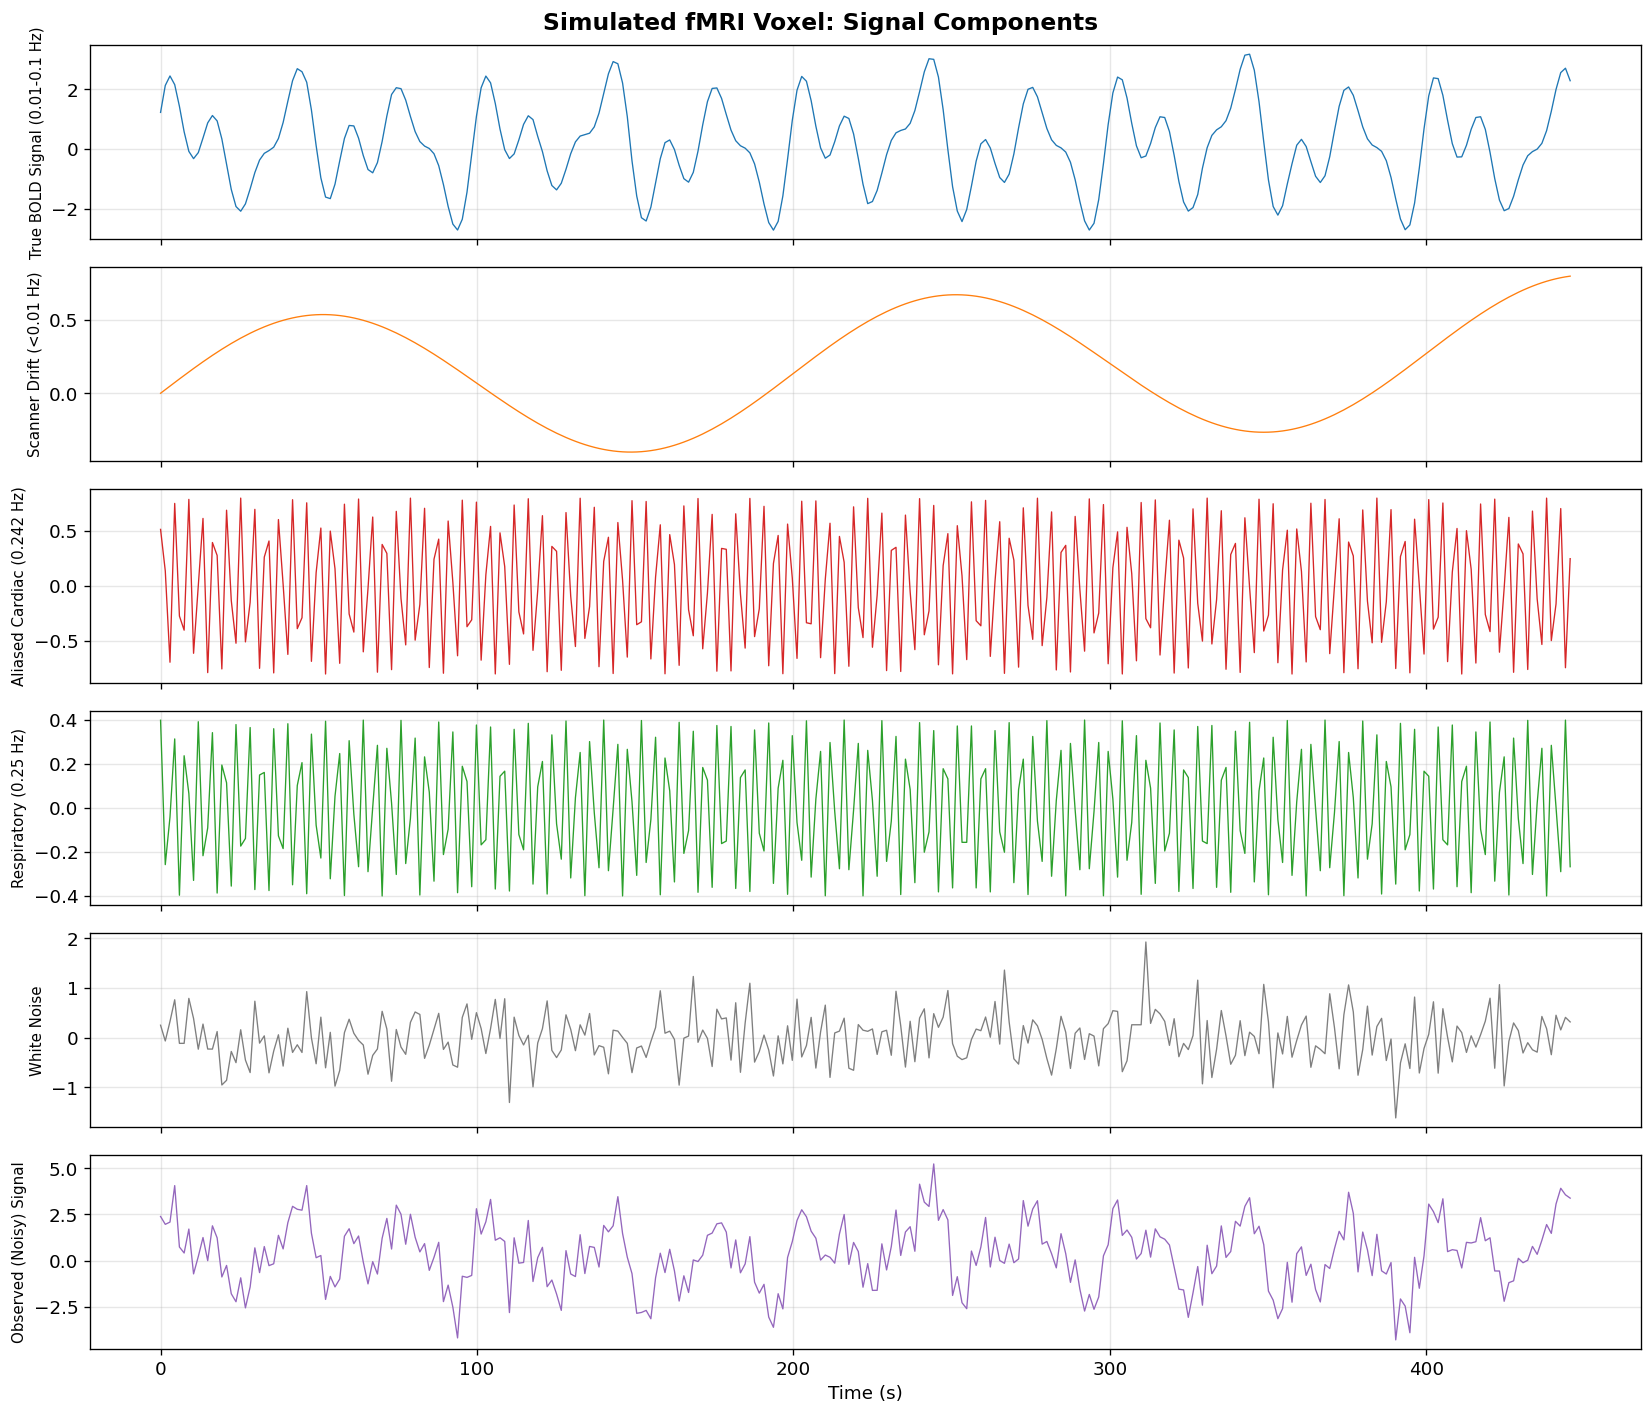

In [3]:
np.random.seed(42)

# 1. True BOLD signal (task-related, 0.01-0.1 Hz)
bold_signal = (
    1.5 * np.sin(2 * np.pi * 0.03 * t) +  # slow BOLD oscillation
    1.0 * np.sin(2 * np.pi * 0.07 * t + 0.5) +  # faster BOLD component
    0.8 * np.sin(2 * np.pi * 0.05 * t + 1.2)  # mid BOLD
)
# Add event-related transients (simulating movie scene changes)
for onset in [30, 80, 150, 220]:
    if onset < n_timepoints:
        hrf = np.zeros(n_timepoints)
        tau = np.arange(min(20, n_timepoints - onset))
        hrf[onset:onset+len(tau)] = 2.0 * (tau/5.0) * np.exp(-tau/5.0)
        bold_signal += hrf

# 2. Low-frequency drift (scanner artifact)
drift = 0.5 * np.sin(2 * np.pi * 0.005 * t) + 0.3 * t / t[-1]

# 3. Cardiac noise (~1 Hz, aliased to ~0.33 Hz at TR=1.49s)
f_cardiac_true = 1.1  # Hz
f_cardiac_aliased = abs(f_cardiac_true - round(f_cardiac_true / fs) * fs)
cardiac_noise = 0.8 * np.sin(2 * np.pi * f_cardiac_aliased * t + 0.7)
print(f"Cardiac {f_cardiac_true} Hz → aliased to {f_cardiac_aliased:.4f} Hz")

# 4. Respiratory noise (~0.25 Hz, within Nyquist)
respiratory_noise = 0.4 * np.sin(2 * np.pi * 0.25 * t + 1.5)

# 5. White noise
white_noise = 0.5 * np.random.randn(n_timepoints)

# Composite signals
clean_signal = bold_signal
noise = drift + cardiac_noise + respiratory_noise + white_noise
noisy_signal = clean_signal + noise

# Visualization
fig, axes = plt.subplots(6, 1, figsize=(14, 12), sharex=True)
components = [
    (bold_signal, 'True BOLD Signal (0.01-0.1 Hz)', 'tab:blue'),
    (drift, 'Scanner Drift (<0.01 Hz)', 'tab:orange'),
    (cardiac_noise, f'Aliased Cardiac ({f_cardiac_aliased:.3f} Hz)', 'tab:red'),
    (respiratory_noise, 'Respiratory (0.25 Hz)', 'tab:green'),
    (white_noise, 'White Noise', 'tab:gray'),
    (noisy_signal, 'Observed (Noisy) Signal', 'tab:purple'),
]
for ax, (sig, title, color) in zip(axes, components):
    ax.plot(t, sig, color=color, lw=0.8)
    ax.set_ylabel(title, fontsize=9)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Simulated fMRI Voxel: Signal Components', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2. The Aliasing Problem Visualized

This section demonstrates why cardiac noise at ~1 Hz **cannot** be removed by a simple notch filter when TR = 1.49s.


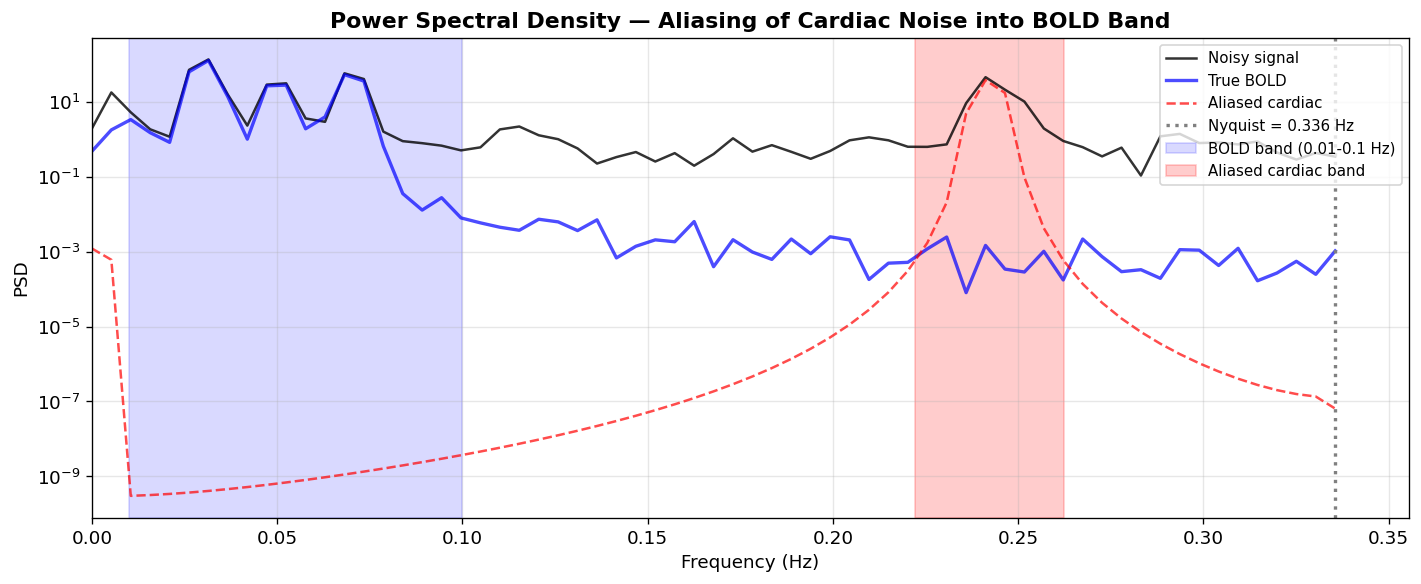


⚠️  Cardiac noise at 1.1 Hz aliases to 0.2423 Hz
   This overlaps with the BOLD signal band (0.01-0.1 Hz)!
   A notch filter at 1 Hz is USELESS — the aliased frequency is already below Nyquist.


In [4]:
from scipy.signal import welch

freqs, psd_noisy = welch(noisy_signal, fs=fs, nperseg=min(128, n_timepoints//2))
freqs, psd_bold = welch(bold_signal, fs=fs, nperseg=min(128, n_timepoints//2))
freqs, psd_cardiac = welch(cardiac_noise, fs=fs, nperseg=min(128, n_timepoints//2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(freqs, psd_noisy, 'k-', lw=1.5, label='Noisy signal', alpha=0.8)
ax.semilogy(freqs, psd_bold, 'b-', lw=2, label='True BOLD', alpha=0.7)
ax.semilogy(freqs, psd_cardiac, 'r--', lw=1.5, label='Aliased cardiac', alpha=0.7)

ax.axvline(f_nyquist, color='gray', ls=':', lw=2, label=f'Nyquist = {f_nyquist:.3f} Hz')
ax.axvspan(0.01, 0.1, alpha=0.15, color='blue', label='BOLD band (0.01-0.1 Hz)')
ax.axvspan(f_cardiac_aliased - 0.02, f_cardiac_aliased + 0.02, alpha=0.2, color='red',
           label=f'Aliased cardiac band')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD')
ax.set_title('Power Spectral Density — Aliasing of Cardiac Noise into BOLD Band', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, f_nyquist + 0.02)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n⚠️  Cardiac noise at {f_cardiac_true} Hz aliases to {f_cardiac_aliased:.4f} Hz")
print(f"   This overlaps with the BOLD signal band (0.01-0.1 Hz)!")
print(f"   A notch filter at 1 Hz is USELESS — the aliased frequency is already below Nyquist.")


## 3. Wavelet Decomposition: DWT vs SWT (MODWT proxy)

### DWT (Discrete Wavelet Transform)
- Decimates (downsamples) at each level → loses temporal resolution
- Sensitive to shifts in the input signal

### SWT (Stationary Wavelet Transform) ≈ MODWT
- **No downsampling** — all coefficient arrays have the same length as the input
- **Shift-invariant** — small shifts in input don't drastically change coefficients
- Better suited for time-series denoising (fMRI)

PyWavelets' `pywt.swt` is functionally equivalent to MODWT for denoising purposes.


Wavelet: db4, Decomposition level: 2 (max possible: 2)

Frequency bands per decomposition level:
Level    Band (Hz)            Content
-------------------------------------------------------
D1       0.1678 – 0.3356 Hz     Cardiac ✗, Respiratory ✗
D2       0.0839 – 0.1678 Hz     BOLD ✓
A2       0 – 0.0839 Hz          Drift, slow BOLD


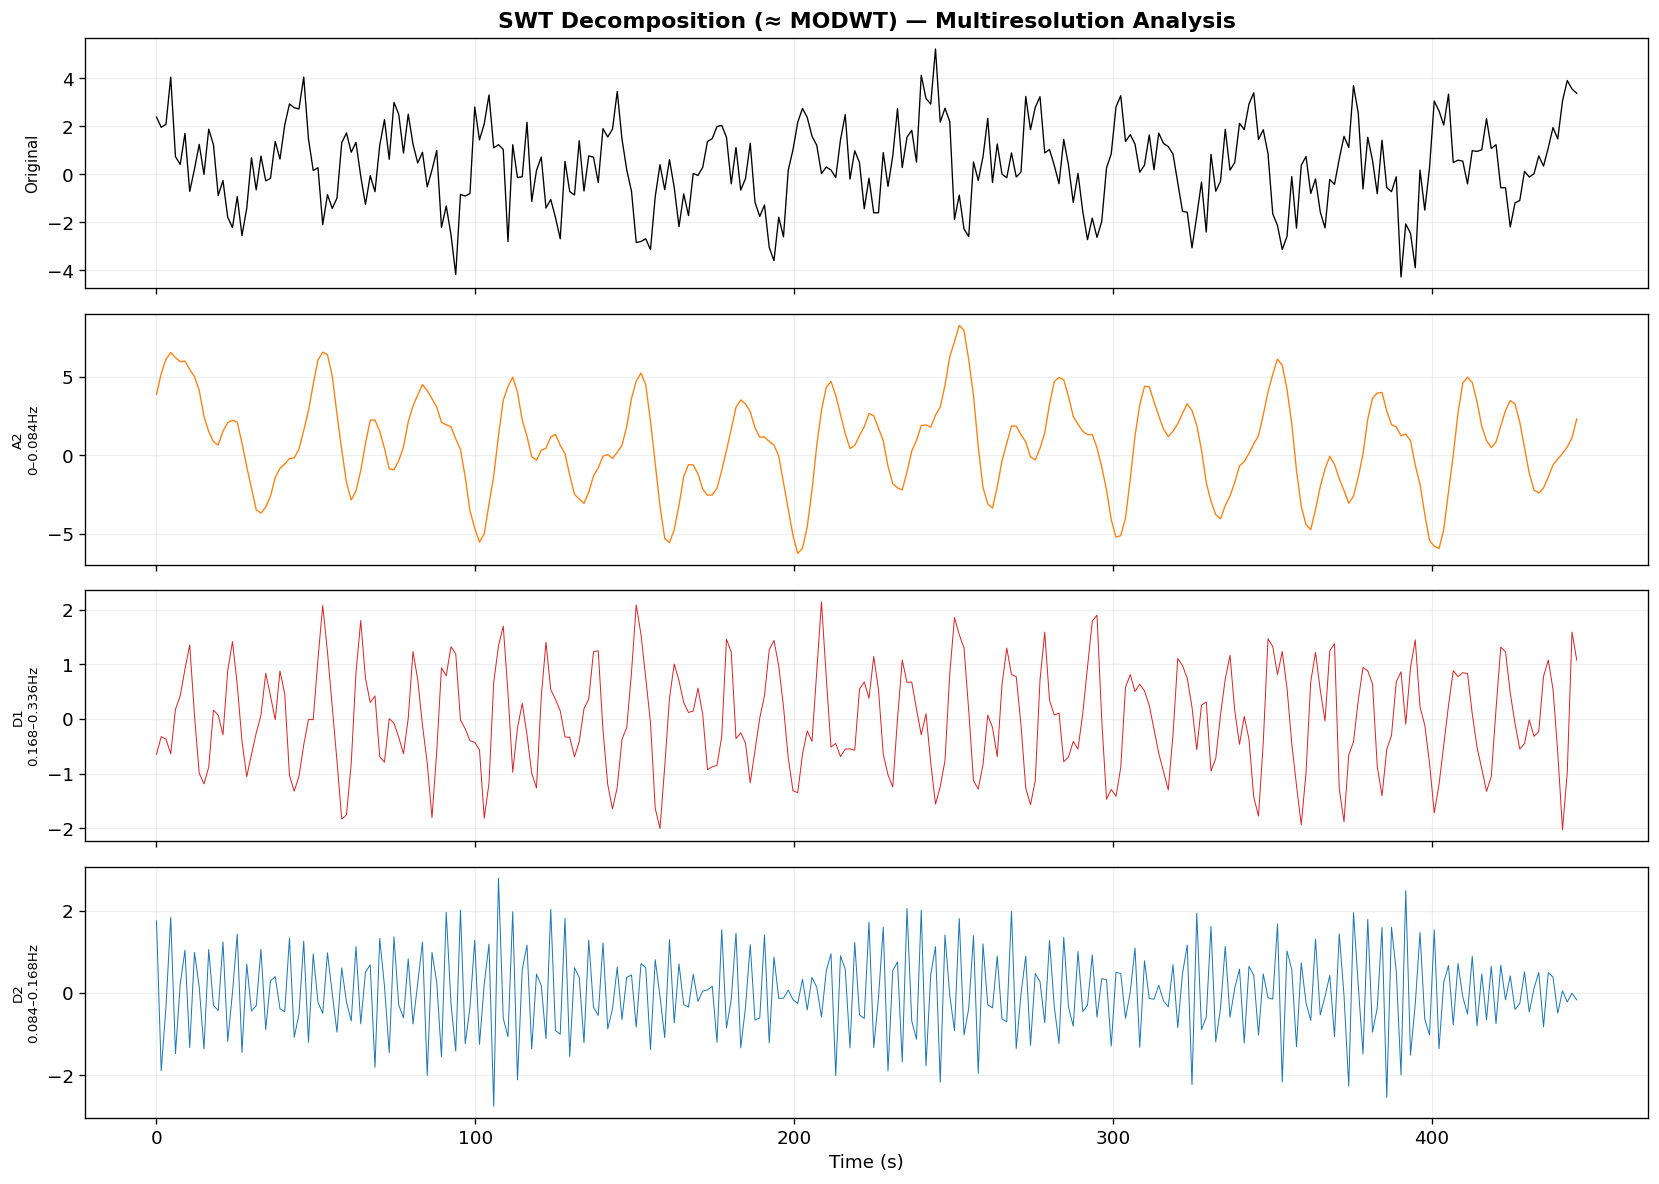

In [5]:
wavelet = 'db4'
max_level = pywt.swt_max_level(n_timepoints)
level = min(5, max_level)
print(f"Wavelet: {wavelet}, Decomposition level: {level} (max possible: {max_level})")

# DWT decomposition
dwt_coeffs = pywt.wavedec(noisy_signal, wavelet, level=level)

# SWT decomposition (MODWT proxy)
swt_coeffs = pywt.swt(noisy_signal, wavelet, level=level, trim_approx=True)

print("\nFrequency bands per decomposition level:")
print(f"{'Level':<8} {'Band (Hz)':<20} {'Content'}")
print("-" * 55)
for i in range(1, level + 1):
    f_low = fs / (2**(i+1))
    f_high = fs / (2**i)
    content = []
    if f_low < 0.1 and f_high > 0.01:
        content.append('BOLD ✓')
    if f_low < f_cardiac_aliased < f_high:
        content.append('Cardiac ✗')
    if f_low < 0.25 < f_high:
        content.append('Respiratory ✗')
    print(f"D{i:<7} {f_low:.4f} – {f_high:.4f} Hz     {', '.join(content) if content else 'Other'}")
f_approx = fs / (2**(level+1))
print(f"A{level:<7} 0 – {f_approx:.4f} Hz          {'Drift, slow BOLD'}")

fig, axes = plt.subplots(level + 2, 1, figsize=(14, 2.5 * (level + 2)), sharex=True)

axes[0].plot(t, noisy_signal, 'k', lw=0.8)
axes[0].set_ylabel('Original', fontsize=9)
axes[0].set_title('SWT Decomposition (≈ MODWT) — Multiresolution Analysis', fontweight='bold')

axes[1].plot(t, swt_coeffs[0], color='tab:orange', lw=0.8)
axes[1].set_ylabel(f'A{level}\n0–{f_approx:.3f}Hz', fontsize=8)

for i in range(1, level + 1):
    ax = axes[i + 1]
    detail = swt_coeffs[i]
    f_low = fs / (2**(i+1))
    f_high = fs / (2**i)
    color = 'tab:red' if abs(f_cardiac_aliased - (f_low+f_high)/2) < (f_high-f_low) else 'tab:blue'
    ax.plot(t, detail, color=color, lw=0.6)
    ax.set_ylabel(f'D{i}\n{f_low:.3f}–{f_high:.3f}Hz', fontsize=8)

axes[-1].set_xlabel('Time (s)')
for ax in axes:
    ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 4. Thresholding Methods

| Method | Formula / Properties |
|--------|----------------------|
| **VisuShrink** | $\lambda = \sigma \sqrt{2 \ln N}$. Universal, tends to over-smooth |
| **SureShrink** | SURE-optimal per subband. Adaptive, good detail preservation |
| **BayesShrink** | $\lambda = \sigma^2 / \sigma_s$. Bayesian-optimal, best for signals/images |


In [6]:
def estimate_noise_std(detail_coeffs):
    return np.median(np.abs(detail_coeffs)) / 0.6745

def visu_threshold(detail_coeffs):
    sigma = estimate_noise_std(detail_coeffs)
    return sigma * np.sqrt(2 * np.log(len(detail_coeffs)))

def bayes_threshold(detail_coeffs):
    sigma = estimate_noise_std(detail_coeffs)
    sigma2 = sigma ** 2
    sigma2_y = np.mean(detail_coeffs ** 2)
    sigma_s = np.sqrt(max(sigma2_y - sigma2, 0))
    if sigma_s < 1e-10:
        return np.max(np.abs(detail_coeffs))
    return sigma2 / sigma_s

def sure_threshold(detail_coeffs):
    n = len(detail_coeffs)
    sigma = estimate_noise_std(detail_coeffs)
    if sigma < 1e-10: return 0.0
    d = detail_coeffs / sigma
    d_sorted = np.sort(d**2)
    risks = np.zeros(n)
    for i in range(n):
        lam2 = d_sorted[i]
        risks[i] = (n - 2 * (i + 1) + np.sum(np.minimum(d_sorted, lam2))) / n
    best_idx = np.argmin(risks)
    return sigma * np.sqrt(d_sorted[best_idx])

def wavelet_denoise(signal, wavelet='db4', level=None, threshold_fn=visu_threshold, mode='soft'):
    if level is None:
        level = min(5, pywt.swt_max_level(len(signal)))
    
    coeffs = pywt.swt(signal, wavelet, level=level, trim_approx=True)
    denoised_coeffs = [coeffs[0]]
    thresholds = []
    
    for i in range(1, len(coeffs)):
        detail = coeffs[i]
        lam = threshold_fn(detail)
        thresholds.append(lam)
        denoised_detail = pywt.threshold(detail, lam, mode=mode)
        denoised_coeffs.append(denoised_detail)
    
    # Custom reconstruction for trim_approx=True
    # pywt.iswt expects [(cA_n, cD_n), (cA_n-1, cD_n-1), ...]
    rec_coeffs = []
    curr_cA = denoised_coeffs[0]
    for i in range(1, level + 1):
        cD = denoised_coeffs[-i]
        rec_coeffs.append((curr_cA, cD))
        if i < level:
            curr_cA = pywt.iswt([(curr_cA, cD)], wavelet)
    
    reconstructed = pywt.iswt(rec_coeffs, wavelet)
    return reconstructed[:len(signal)], thresholds

results = {}
for name, fn in [('VisuShrink', visu_threshold), ('BayesShrink', bayes_threshold), ('SureShrink', sure_threshold)]:
    denoised, thresholds = wavelet_denoise(noisy_signal, wavelet='db4', level=level, threshold_fn=fn, mode='soft')
    corr = np.corrcoef(denoised, clean_signal)[0, 1]
    snr = 10 * np.log10(np.var(clean_signal) / np.mean((denoised - clean_signal)**2))
    results[name] = {'denoised': denoised, 'corr': corr, 'snr': snr}
    print(f"{name:12s}: PCC={corr:.4f}, SNR={snr:.2f}dB")

noisy_corr = np.corrcoef(noisy_signal, clean_signal)[0, 1]
noisy_snr = 10 * np.log10(np.var(clean_signal) / np.mean((noisy_signal - clean_signal)**2))
print(f"\n{'Noisy':12s}: PCC={noisy_corr:.4f}, SNR={noisy_snr:.2f}dB")


VisuShrink  : PCC=0.9540, SNR=9.48dB
BayesShrink : PCC=0.9540, SNR=9.48dB
SureShrink  : PCC=0.9540, SNR=9.48dB

Noisy       : PCC=0.8571, SNR=3.74dB


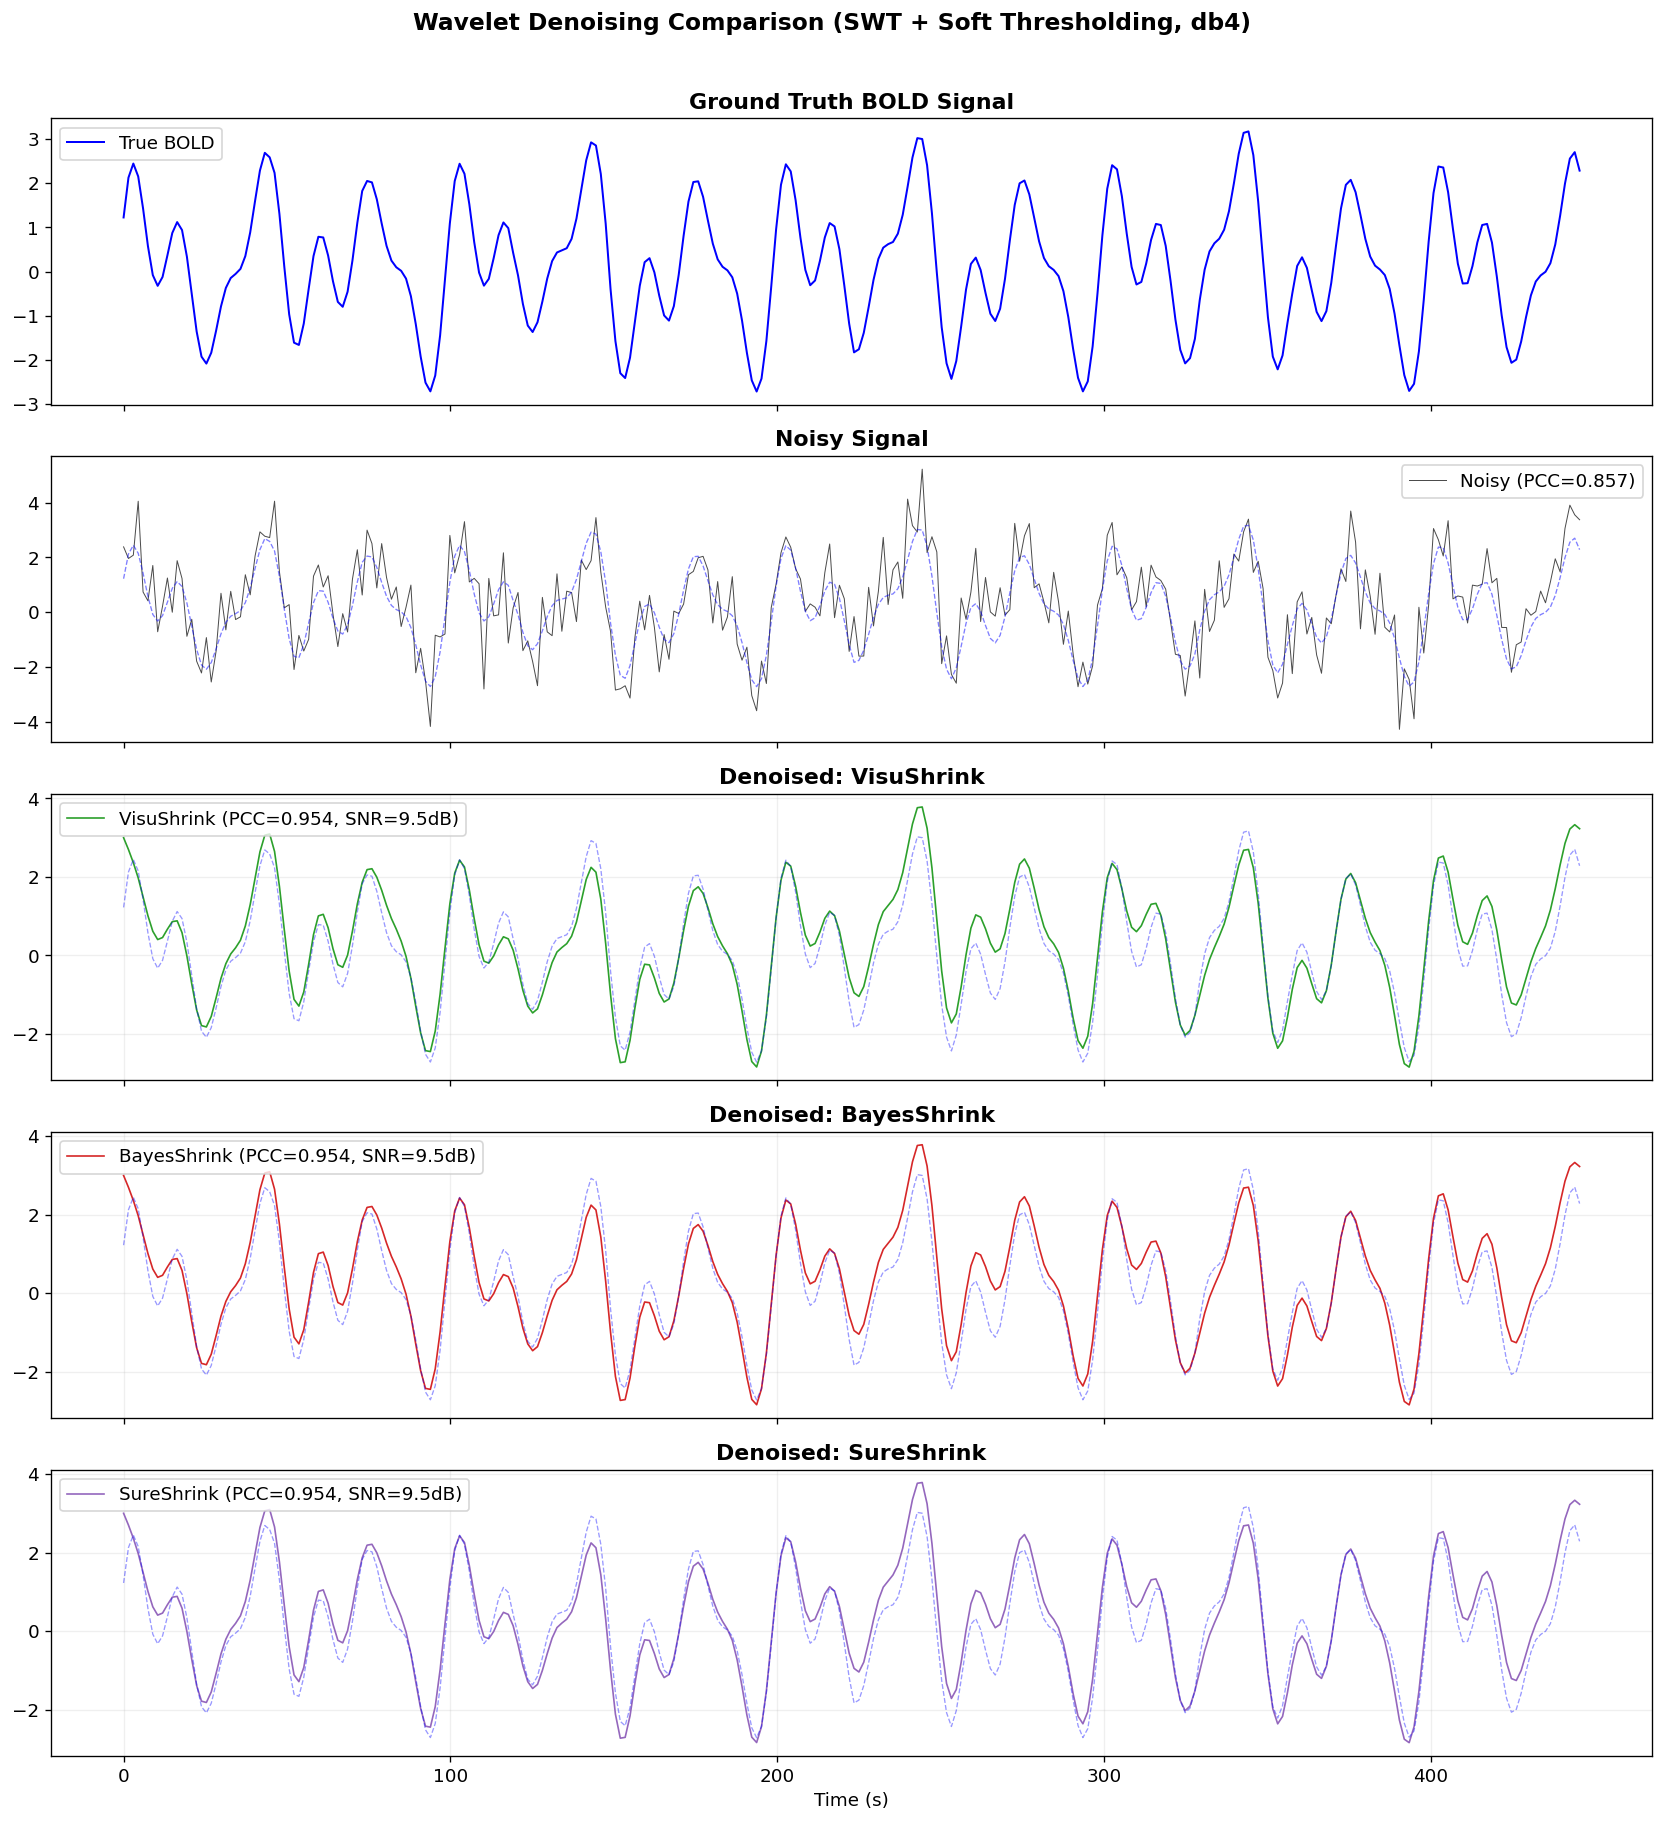

In [7]:
fig, axes = plt.subplots(len(results) + 2, 1, figsize=(14, 3 * (len(results) + 2)), sharex=True)

axes[0].plot(t, clean_signal, 'b-', lw=1.2, label='True BOLD')
axes[0].set_title('Ground Truth BOLD Signal', fontweight='bold')
axes[0].legend()

axes[1].plot(t, noisy_signal, 'k-', lw=0.6, alpha=0.7, label=f'Noisy (PCC={noisy_corr:.3f})')
axes[1].plot(t, clean_signal, 'b--', lw=0.8, alpha=0.5)
axes[1].set_title('Noisy Signal', fontweight='bold')
axes[1].legend()

colors = {'VisuShrink': 'tab:green', 'BayesShrink': 'tab:red', 'SureShrink': 'tab:purple'}
for ax, (name, res) in zip(axes[2:], results.items()):
    ax.plot(t, res['denoised'], color=colors[name], lw=1, label=f"{name} (PCC={res['corr']:.3f}, SNR={res['snr']:.1f}dB)")
    ax.plot(t, clean_signal, 'b--', lw=0.8, alpha=0.4)
    ax.set_title(f'Denoised: {name}', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Wavelet Denoising Comparison (SWT + Soft Thresholding, db4)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Multi-Voxel Simulation & Recommendations
In Algonauts 2025, each TR has 1000 voxels.

**Recommendations:**
- **Wavelet family**: `db4` or `db8`
- **Method**: SWT (MODWT proxy)
- **Threshold**: Soft thresholding with **BayesShrink**
- **Strategy**: Denoise each voxel's time series *independently* before computing global normalization.
